# 20260721 pairwise interaction — relative abundance & competitive hierarchy

**Reference**: `analysis/consensus/merged_consensus_20260721.fasta` (this experiment's own
per-strain consensus). **Guide**: `setup/strain_layout_20260721_plate1_2_swapped.csv`.
**Cohort**: the same ">5 reads" pair wells already identified in
`analysis/mapping_validation` (2,618 wells).

Four questions, one pipeline each (`scripts/r01`-`r06`):

1. **Interaction score per well** — assuming only strain1/strain2 are present, what's each
   one's relative abundance? Reads that match neither are quantified, not discarded. Strain
   pairs whose references are (near-)identical are still *run through the same classifier
   first* — "can't be told apart → 50/50" falls out of the general method automatically
   (zero separating signal ⇒ every read is unassignable ⇒ exactly 50/50), rather than being
   special-cased from reference distance alone. A pair a few bp apart is never assumed
   indistinguishable up front; the data decides.
2. **Replicate stability** — for strain pairs plated more than once, does the interaction
   score reproduce, or move around?
3. **Per-strain competitiveness score** — averaged across every opponent a strain faced.
4. **Hierarchy vs. tangled network** — does a single dominance ranking explain this library's
   competitive outcomes, or is it closer to a cyclic, rock-paper-scissors-like network?


In [1]:
import sys
from pathlib import Path

NB_DIR = Path.cwd()
SCRIPTS_DIR = NB_DIR / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))

import pandas as pd
from IPython.display import Image, display, Markdown

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

from ra_common import OUT_DIR, FIG_DIR, REFERENCE_FASTA, SAMPLES_GT5READS_CSV

def show(png_name, width=880):
    display(Image(filename=str(FIG_DIR / png_name), width=width))

print(f"reference -> {REFERENCE_FASTA}")
print(f"cohort    -> {SAMPLES_GT5READS_CSV}")
print(f"outputs   -> {OUT_DIR}")


reference -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/consensus/merged_consensus_20260721.fasta
cohort    -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/mapping_validation/outputs/01_samples_gt5reads.csv
outputs   -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/relative_abundance/outputs


## Step 1 — reference-pair distances

For every unique strain pair actually tested, how far apart are the two strains' *own*
reference sequences? This is pure context for everything downstream: if two references are
(near-)identical, no method can discriminate their reads, no matter how good it is.


In [2]:
from r01_reference_distances import compute_reference_distances

ref_dist = compute_reference_distances()
display(ref_dist.sort_values("bp_dist").head(10))


2159 unique tested strain pairs (40 missing a reference for one strain)
reference-pair bp distance among resolvable pairs: min=0, median=208, max=408
pairs with identical (0 bp) references: 1
pairs with <10 bp difference: 31
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/relative_abundance/outputs/r01_reference_pair_distances.csv


,strain_a,strain_b,bp_dist,norm_dist,len_a,len_b,missing_reference
1349,F2,K11,0.0,0.000000,1422.0,1422.0,False
1359,F2,N23,2.0,0.001406,1422.0,1422.0,False
1366,F2,P14,2.0,0.001406,1422.0,1422.0,False
1714,K11,N23,2.0,0.001406,1422.0,1422.0,False
800,C8,K11,2.0,0.001406,1422.0,1422.0,False
796,C8,F2,2.0,0.001406,1422.0,1422.0,False
1716,K11,N3,3.0,0.002110,1422.0,1422.0,False
1355,F2,M15,3.0,0.002110,1422.0,1422.0,False
1360,F2,N3,3.0,0.002110,1422.0,1422.0,False
870,D11,F17,3.0,0.002123,1413.0,1413.0,False


31 of 2,159 tested pairs are within 10bp of each other, including one pair (`F2`/`K11`)
whose references are **completely identical** (0bp apart) — and inspection of the broader
distance table shows these aren't isolated coincidences but a small cluster of strains
(`F2`, `K11`, `C8`, `N23`, `P14`, `M15`, `N3`, ...) whose 16S sequences are all within a few
bp of each other. Full-length 16S genuinely cannot resolve strain identity within this
cluster.


## Step 2 — per-well interaction scoring

Every read in every pair well is classified against its well's two candidate references
(edlib normalized edit distance): `strain1`, `strain2`, `ambiguous` (on-target, but the
margin between the two distances is too small to call), or `off_target` (doesn't match
either candidate well). See the script docstring for full detail on why this single method
handles both "normal" wells and "references are identical" wells without a special case.


In [3]:
from r02_well_interaction_scores import compute_interaction_scores

wells, reads = compute_interaction_scores()


2618 pair wells (48 skipped, missing a reference for one strain)
110282 reads classified -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/relative_abundance/outputs/r02_read_assignments.csv.gz
read_class breakdown:
read_class
strain2       39026
strain1       38990
ambiguous     20988
off_target    11278

median off_target_frac: 0.025
median uncertainty_score: 0.000
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/relative_abundance/outputs/r02_well_interaction_scores.csv


In [4]:
display(Markdown("**A concrete illustration** -- an indistinguishable pair vs. a well-separated one:"))
example_cols = ["sample_id", "strain1", "strain2", "n_reads", "ref_pair_bp_dist",
                "uncertainty_score", "relative_abundance_strain1", "log2_ratio_strain1_over_strain2"]
indistinguishable = wells[(wells.ref_pair_bp_dist == 0)]
separated = wells.sort_values("ref_pair_bp_dist", ascending=False).head(1)
display(pd.concat([indistinguishable, separated])[example_cols])


**A concrete illustration** -- an indistinguishable pair vs. a well-separated one:

,sample_id,strain1,strain2,n_reads,ref_pair_bp_dist,uncertainty_score,relative_abundance_strain1,log2_ratio_strain1_over_strain2
83,Plate01_F21,K11,F2,102,0.0,1.0,0.500000,0.000000
2252,Plate18_K8,C11,B12,36,408.0,0.0,0.888889,2.852443


**Read classification & per-well quality** (off-target fraction, uncertainty score) and the overall interaction-outcome distribution:

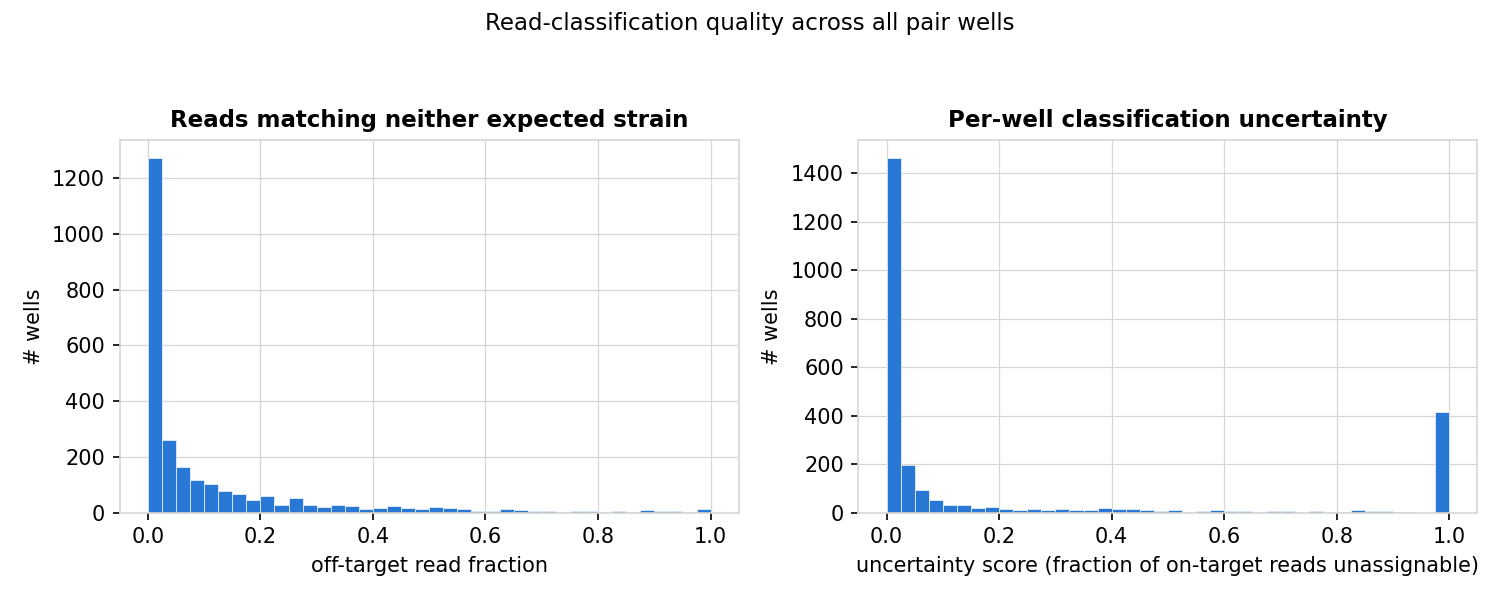

In [5]:
show("00_read_classification_quality.png")

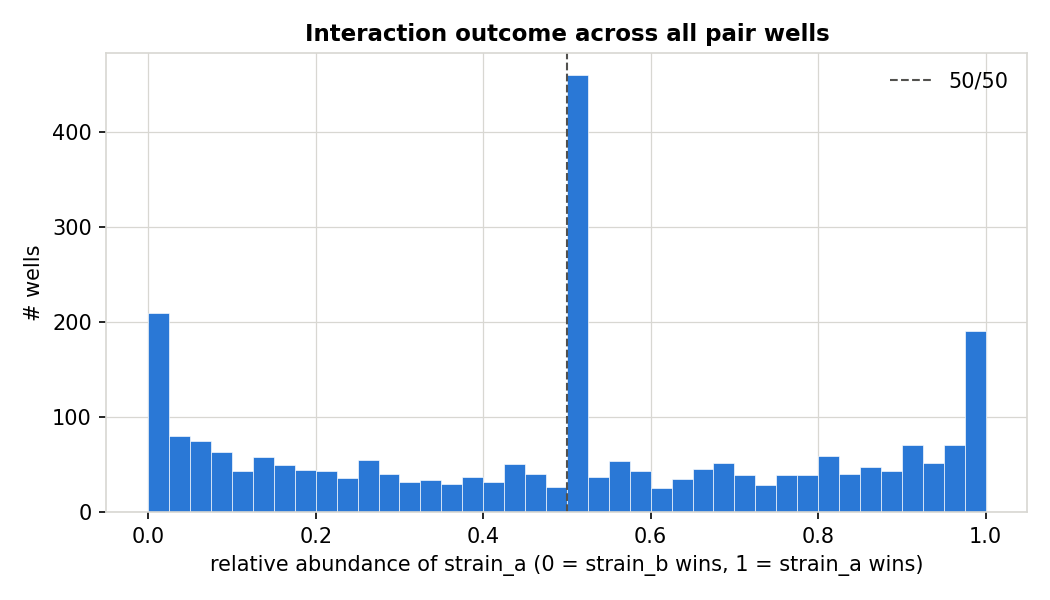

In [6]:
show("01_abundance_distribution.png")

The interaction-outcome histogram shows three regimes at a glance: a spike of wells
where one strain completely excludes the other (near 0 or 1), a spike exactly at 0.5 (the
indistinguishable-reference pairs, correctly reported as maximally uncertain 50/50 rather
than a real coexistence signal), and a broad spread of partial dominance in between.


## Step 3 — replicate stability

For the 445 strain pairs plated more than once: does the interaction score reproduce across
replicate wells? Every well's score is already in a canonical (`strain_a`, `strain_b`)
orientation (`strain_a` < `strain_b` alphabetically) so replicate wells -- which may list
`strain1`/`strain2` in either order -- are directly comparable.


In [7]:
from r03_replicate_stability import compute_replicate_stability

pair_stats = compute_replicate_stability()


2119 unique pairs total; 445 have >=2 replicate wells
  of which 341 are NOT high-uncertainty (reliable measurement)
  median std(relative_abundance_a) across replicated pairs: 0.045
  median std, excluding high-uncertainty pairs: 0.067
  flagged unstable (std > 0.15): 75
  flagged unstable AND not high-uncertainty (genuine biological instability): 73
saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/relative_abundance/outputs/r03_pair_replicate_stats.csv


**Important subtlety**: pairs flagged `high_uncertainty_pair` (near-identical
references) look artificially "stable" across replicates -- they're forced toward 0.5 every
time, which trivially has low variance. That's a measurement ceiling, not evidence the
biology reproduces. The figure below splits the two populations explicitly.


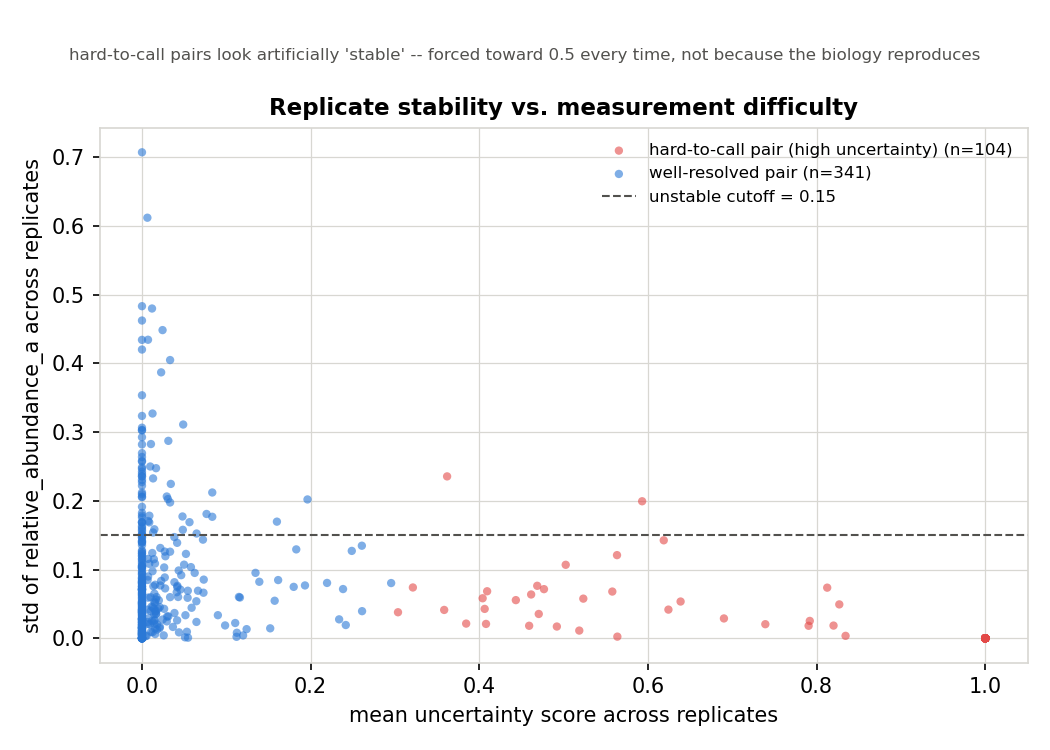

In [8]:
show("02_replicate_stability.png")

In [9]:
unstable = pair_stats[pair_stats.unstable_replicate & ~pair_stats.high_uncertainty_pair]
display(Markdown(f"**{len(unstable)} pairs show genuine (not measurement-driven) replicate instability** "
                  "(std(relative_abundance_a) > 0.15, and the pair is NOT a hard-to-call reference twin):"))
display(unstable.sort_values("std_relative_abundance_a", ascending=False)
        [["strain_a","strain_b","n_replicates","mean_relative_abundance_a","std_relative_abundance_a","mean_uncertainty_score"]]
        .head(10))


**73 pairs show genuine (not measurement-driven) replicate instability** (std(relative_abundance_a) > 0.15, and the pair is NOT a hard-to-call reference twin):

,strain_a,strain_b,n_replicates,mean_relative_abundance_a,std_relative_abundance_a,mean_uncertainty_score
2024,N21,P13,2,0.500000,0.707107,0.000000
1477,G8,P11,2,0.432692,0.611919,0.006410
1726,K17,K3,2,0.508333,0.483190,0.000000
347,B24,C14,2,0.505952,0.479822,0.011905
94,A19,N21,2,0.326923,0.462339,0.000000
977,D20,J24,2,0.317073,0.448409,0.024390
67,A19,B7,2,0.557143,0.434366,0.007143
115,A20,D13,2,0.317995,0.434171,0.000000
1260,F16,O10,2,0.337073,0.420125,0.000000
1898,L6,N10,2,0.608480,0.404829,0.033333


## Step 4 — per-strain competitiveness score

Averaged across every *distinct opponent* a strain was tested against (not every well --
so a heavily-replicated pair doesn't get extra weight). Two axes are reported for each
strain, because they answer different scientific questions:

- **`competitiveness_score`** (mean log2 self/opponent ratio) — does this strain tend to win?
- **dispersion** — is that outcome consistent, or does it depend heavily on the opponent?
  (Computed properly in step 5 below, correcting for opponent strength -- see that section.)


In [10]:
from r04_competitiveness_scores import compute_competitiveness

comp = compute_competitiveness()


86/87 strains scored
  NOT scored (no resolvable reference / no tested pairs survived filtering): ['N13']

top 5 most competitive:
strain  competitiveness_score  win_fraction  n_opponents
   J22               2.849462      0.843137           51
   P16               2.807313      0.877551           49
    G5               2.694224      0.775510           49
   E14               2.432851      0.703704           54
    A5               2.371611      0.796296           54

bottom 5 least competitive:
strain  competitiveness_score  win_fraction  n_opponents
   E24              -2.688150      0.044444           45
   K17              -2.982726      0.060000           50
    N3              -3.080837      0.047619           42
    E3              -3.142059      0.187500           48
   F19              -3.843002      0.066667           45

saved -> /home/rl/scripts/karl/pairwise_interaction_experiments/20260721/analysis/relative_abundance/outputs/r04_strain_competitiveness.csv


**Full competitiveness ranking**, colored by sign (red = tends to dominate, blue = tends to lose):

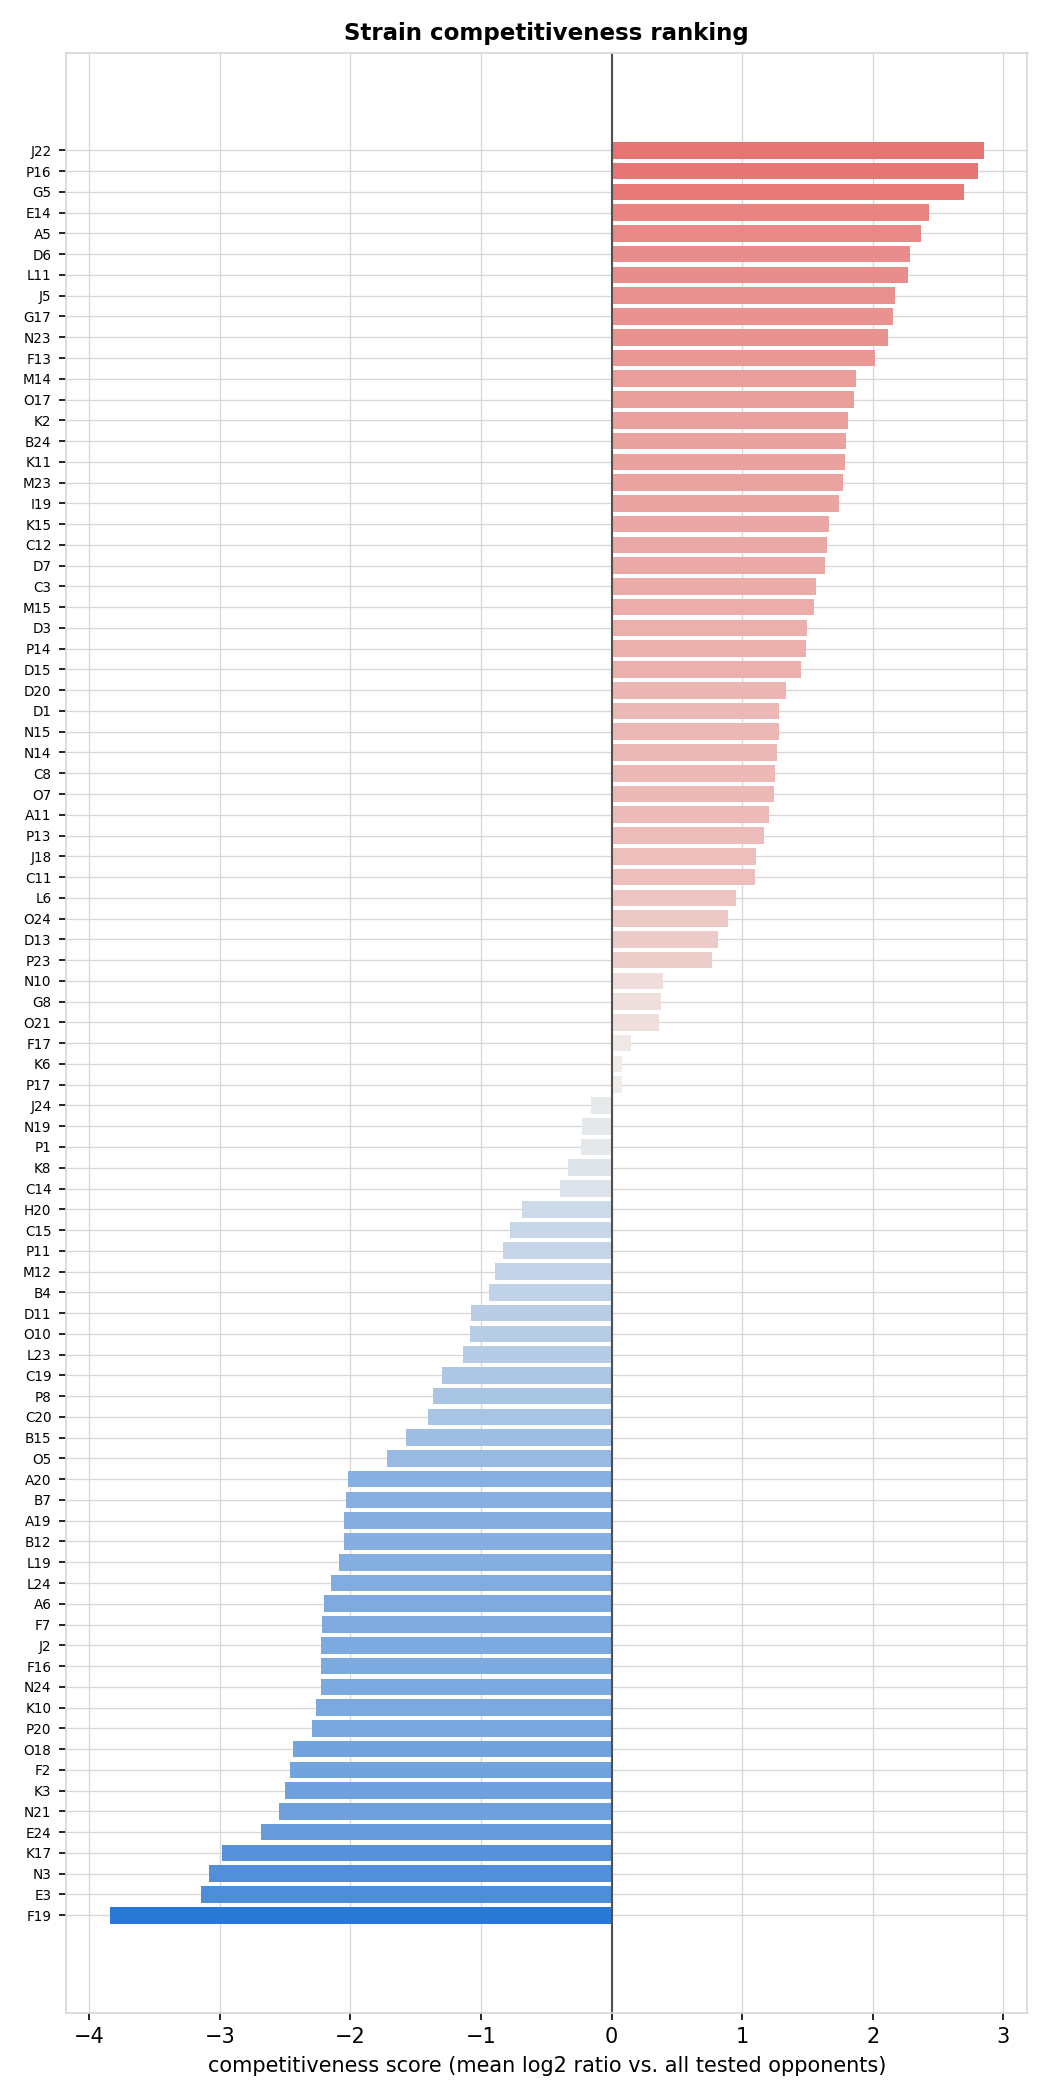

In [11]:
show("03_competitiveness_ranking.png", width=700)

## Step 5 — hierarchy vs. tangled network

Three independent, standard dominance-hierarchy tests (see script docstring for the full
rationale of each):

1. **Bradley-Terry model** — fits one latent "strength" per strain; its pseudo-R² is a
   direct measure of how well a single 1-D ranking explains who wins.
2. **Directional Consistency Index (DCI)** — built for incomplete tournaments (not every
   pair was tested), unlike the classic Landau's h which needs a full round robin.
3. **Intransitive-triad fraction** — among strain triples with all three outcomes known,
   what fraction are cyclic (A beats B beats C beats A)?

We also compute a **BT-residual dispersion** per strain: how far its actual outcome against
each opponent deviates from what its single strength value predicts. This corrects the naive
"spread across opponents" metric from step 4, which is dominated by how strong or weak those
particular opponents happen to be rather than the focal strain's own consistency.


In [12]:
from r05_hierarchy_analysis import hierarchy_analysis

bt, mat, win, hsummary = hierarchy_analysis()


86 strains with resolvable pairwise data
connected components: [86]

Bradley-Terry pseudo-R^2 (deviance explained by a single 1-D strength ranking): 0.798
median BT-residual sd across strains: 2.06 log2 units (the genuine, opponent-strength-corrected unpredictability of a strain's outcomes)
Directional Consistency Index (rank = total wins): 0.694  (1489 consistent, 269 upsets)
Intransitive (cyclic) triads: 378/12138 evaluated (0.031)

saved -> r05_pairwise_relative_abundance_matrix.csv, r05_bt_strengths.csv, r05_hierarchy_summary.csv


In [13]:
display(hsummary)

,metric,value
0,n_strains_in_main_component,86.000000
1,n_components,1.000000
2,bt_pseudo_r2,0.798082
3,dci,0.693970
4,dci_n_consistent,1489.000000
5,dci_n_inconsistent_upsets,269.000000
6,frac_intransitive_triads,0.031142
7,n_intransitive_triads,378.000000
8,n_triads_evaluated,12138.000000


**Pairwise outcome heatmap**, strains ordered by Bradley-Terry strength -- a clean gradient (rather than a scattered/random pattern) is itself the hierarchy signature:

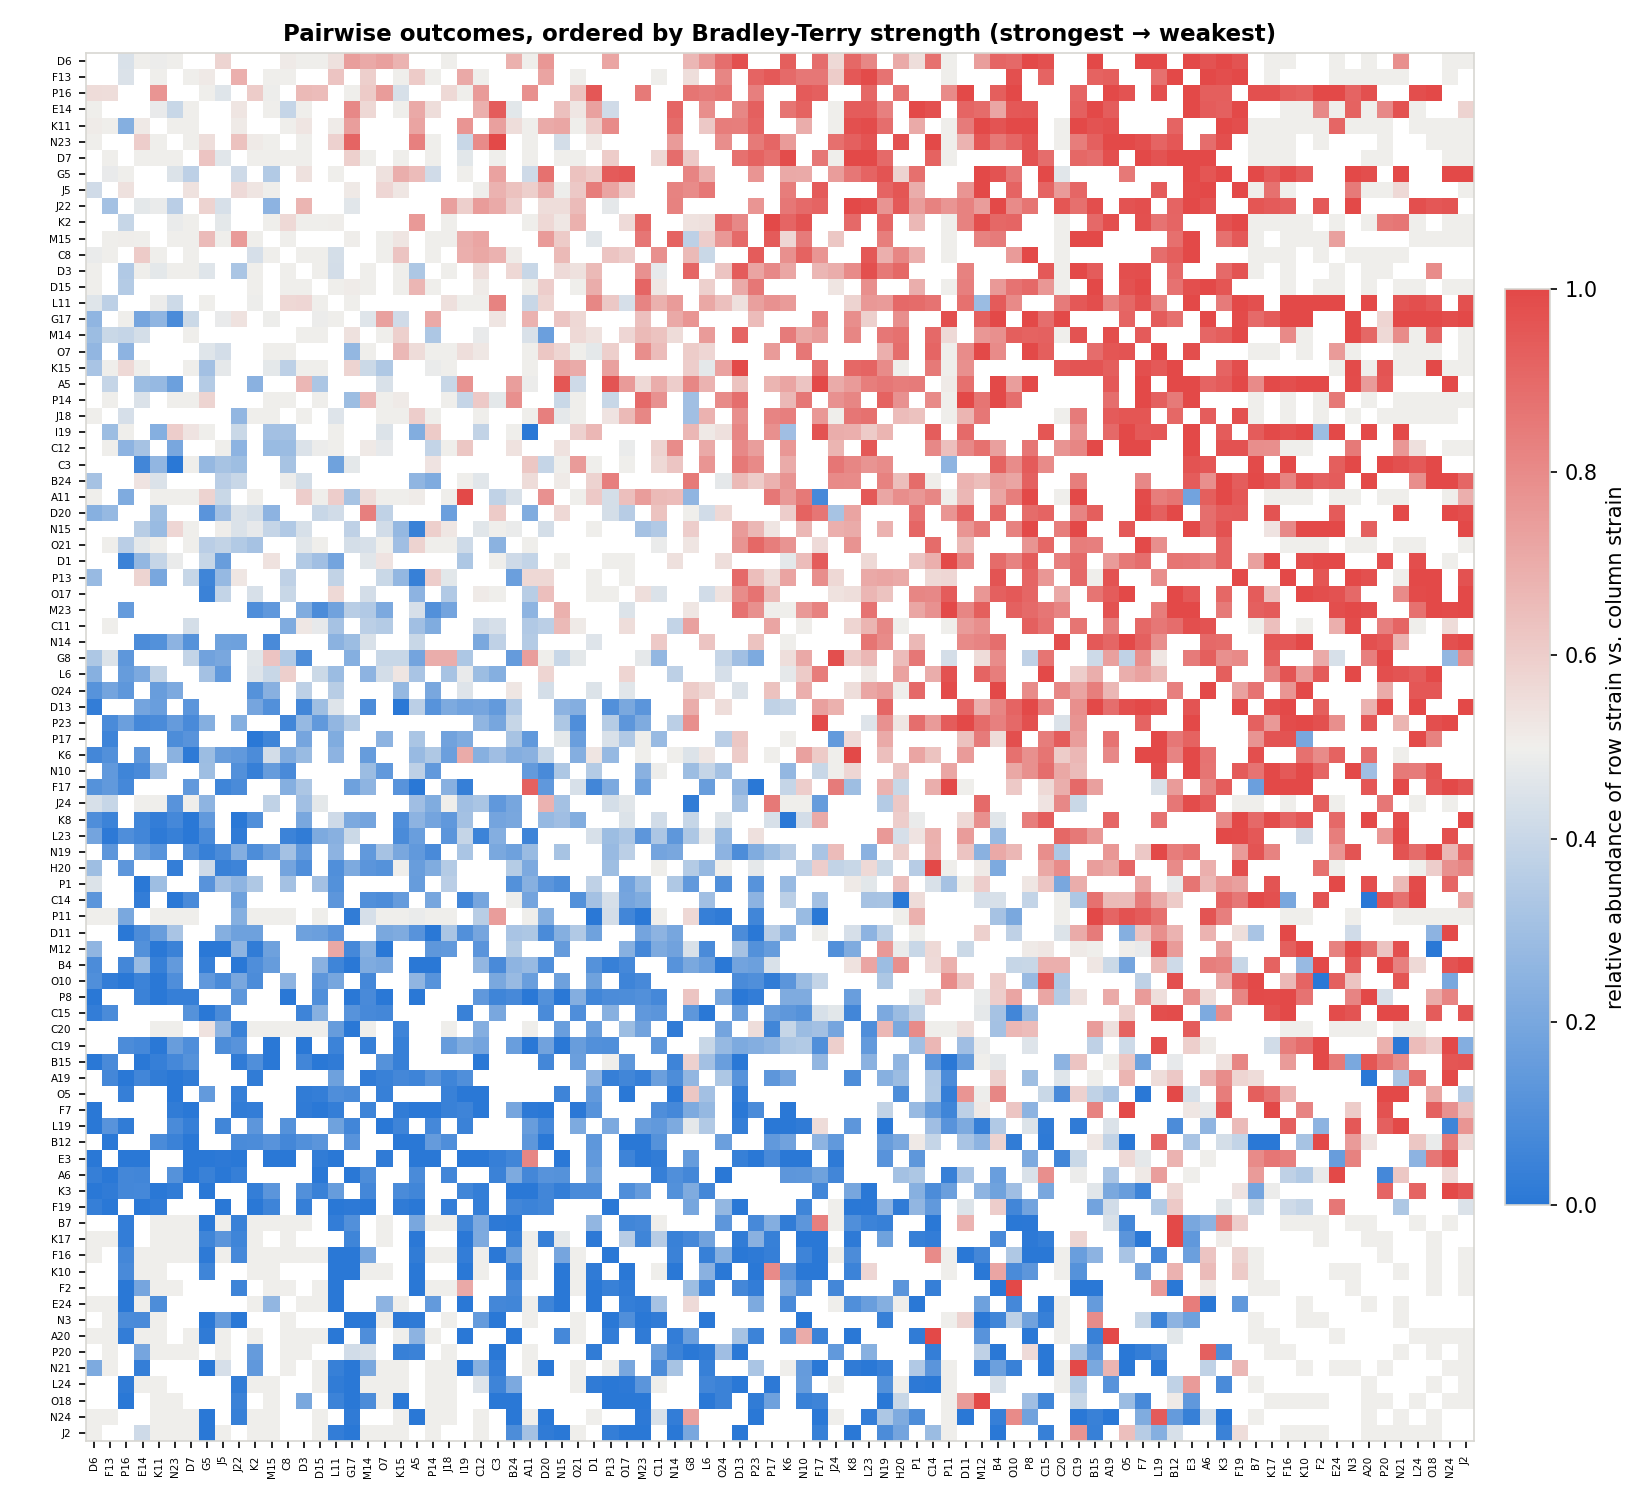

In [14]:
show("05_hierarchy_heatmap.png", width=780)

**Do the two independent competitiveness estimates (step 4's naive average, step 5's model-based strength) agree?**

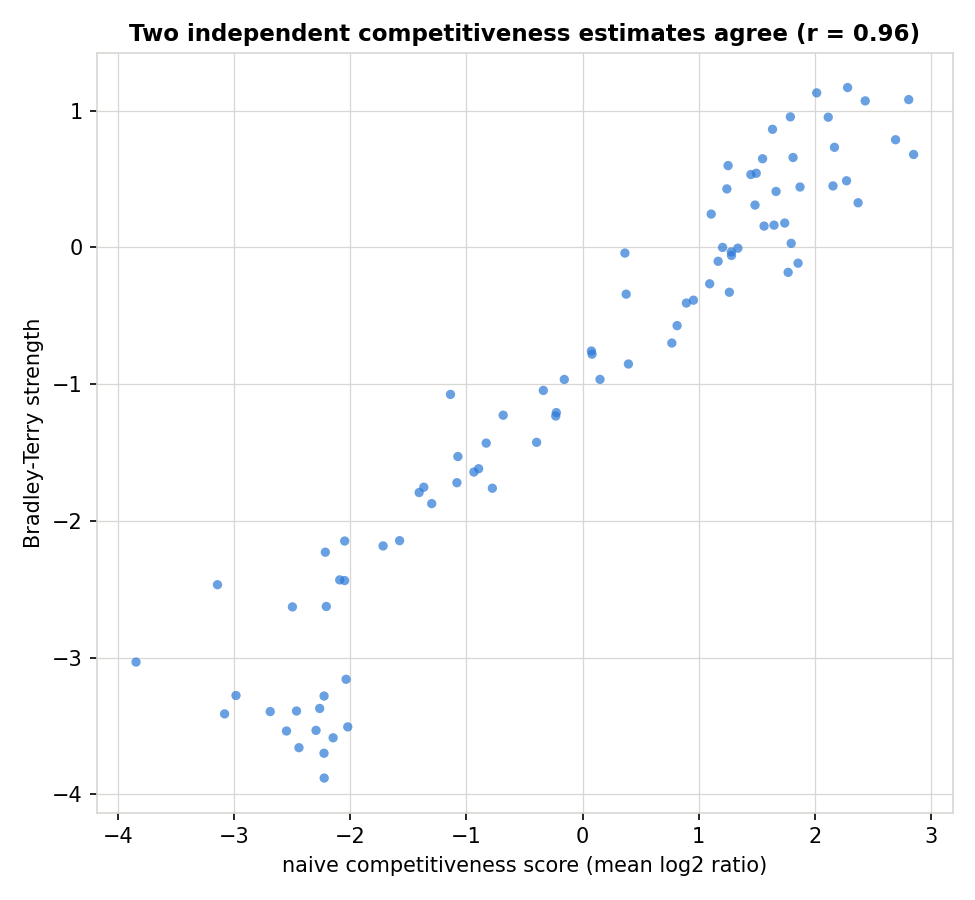

In [15]:
show("06_bt_vs_naive_competitiveness.png", width=520)

**Consistent dominance/loss vs. context-dependent outcomes** (opponent-strength-corrected dispersion):

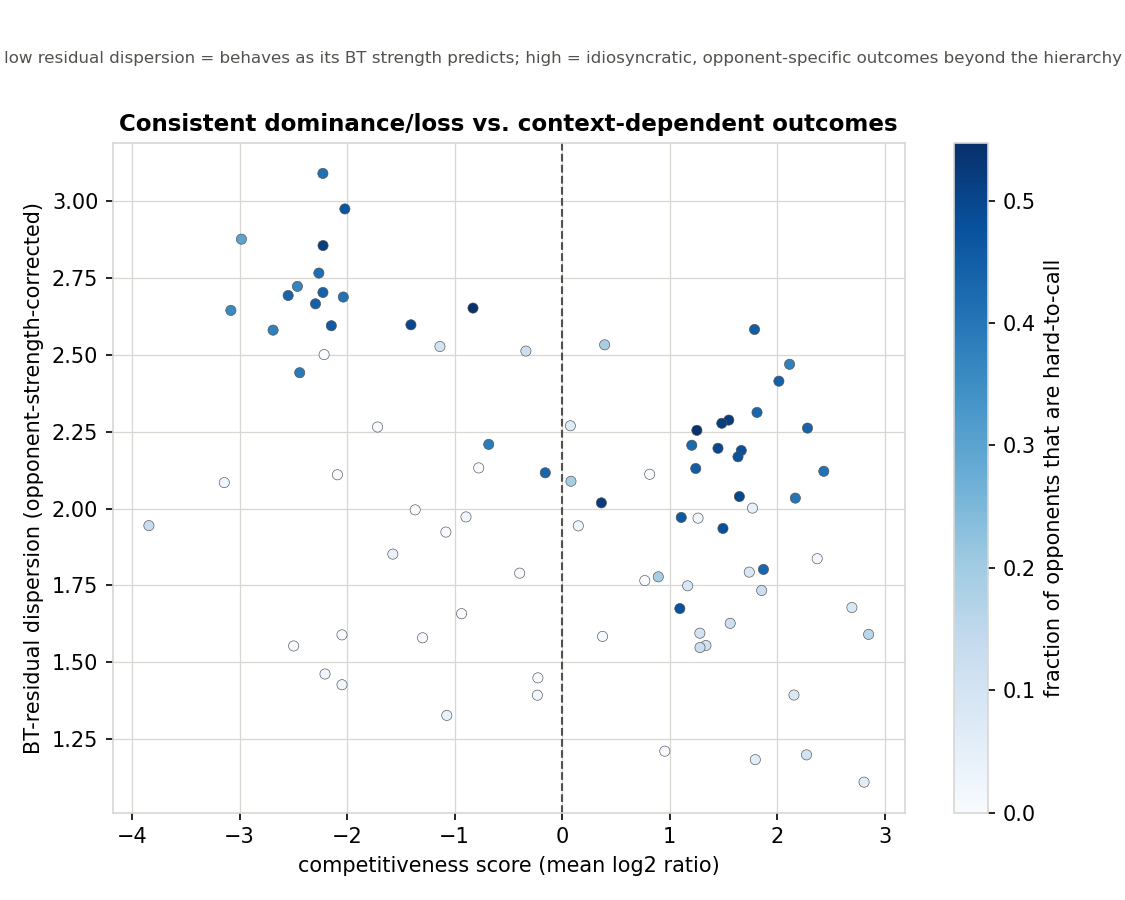

In [16]:
show("04_mean_vs_dispersion.png", width=680)

**Hierarchy consistency, summarized**:

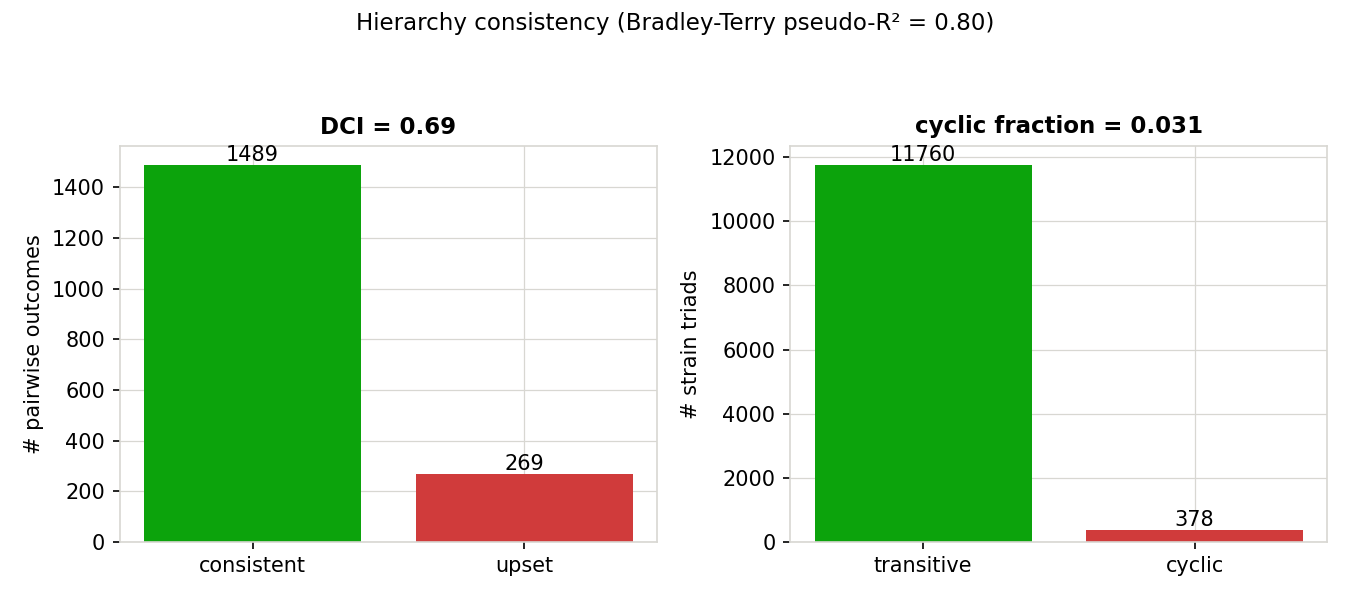

In [17]:
show("07_hierarchy_consistency.png", width=780)

## Key findings

**1. Interaction scores** — computed for 2,570/2,618 pair wells (48 skipped: involve `N13`,
which has no consensus sequence in `merged_consensus_20260721.fasta`). Median off-target
read fraction is only 2.5% (most wells are clean), but 400+ wells are essentially unscoreable
(uncertainty ≈ 1) because their two strains' references are near-identical — correctly
reported as 50/50 with maximal uncertainty rather than silently guessed at.

**2. Replicate stability** — of 445 replicated pairs, most (median std ≈ 0.07 once
hard-to-call pairs are set aside) reproduce reasonably well, but 73 pairs show genuine
replicate instability unexplained by measurement difficulty — real biological
(or plate-position / technical) variability worth a closer look (listed in step 3).

**3. Competitiveness scores** — saved in full for all 86 scorable strains in
`outputs/r04_strain_competitiveness.csv`. `J22`, `P16`, `G5` lead (>75% win rate against ~50
opponents each); `F19`, `E3`, `N3` trail (<19% win rate). Step 5's residual-dispersion figure
adds a second axis: the strongest and weakest strains tend to behave the *most* predictably
(low residual dispersion — they win/lose fairly consistently regardless of opponent), while
mid-ranked strains show more idiosyncratic, opponent-specific outcomes.

**4. Hierarchy, not a tangle** — all three independent tests agree this strain library is
substantially organized as a dominance hierarchy: Bradley-Terry explains ~80% of deviance,
the Directional Consistency Index is 0.69 (1 = perfect linear hierarchy), and only 3.1% of
evaluable strain triples are cyclic. It is not a *pure* hierarchy, though — 269/1,758 tested
outcomes (15%) are "upsets" relative to the overall ranking, and the median BT-residual
dispersion (~2 log2 units, a 4x abundance-ratio's worth) shows meaningful strain-specific
unpredictability beyond a single strength scale.

## Where everything lives

```
analysis/relative_abundance/
├── scripts/                                    numbered, importable pipeline (r01-r06 + ra_common.py)
│                                                (ra_common.py reuses IO helpers from
│                                                 ../mapping_validation/scripts/common.py)
├── outputs/
│   ├── r01_reference_pair_distances.csv        every tested pair's reference-sequence distance
│   ├── r02_read_assignments.csv.gz             per-read classification
│   ├── r02_well_interaction_scores.csv         per-well interaction score + uncertainty
│   ├── r03_pair_replicate_stats.csv            per-pair replicate spread
│   ├── r04_strain_competitiveness.csv          per-strain competitiveness score
│   ├── r05_pairwise_relative_abundance_matrix.csv / r05_bt_strengths.csv / r05_hierarchy_summary.csv
│   └── figures/                                the 8 PNGs shown above
└── <this notebook>
```

Re-running this notebook top to bottom regenerates every output from
`analysis/mapping_validation`'s read cohort and the raw fastqs it references.
